In [2]:
from __future__ import absolute_import, division, print_function

import tensorflow as tf
from tensorflow.keras import Model, layers
import numpy as np

tf.compat.v1.enable_eager_execution()

# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).

# Training parameters.
learning_rate = 0.1
batch_size = 512
display_step = 100

# Network parameters.
n_hidden_1 = 256 # 1st layer number of neurons.


2025-05-30 21:35:38.976475: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-30 21:35:39.079658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748633739.118312  422428 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748633739.129524  422428 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748633739.208874  422428 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:

# Prepare MNIST data.
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Convert to float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
# Flatten images to 1-D vector of 784 features (28*28).
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])
# Normalize images value from [0, 255] to [0, 1].
x_train, x_test = ((x_train / 255.) > 0.5) * 2 - 1, ((x_test / 255.) > 0.5) * 2 - 1
# x_train, x_test = x_train / 255., x_test / 255.

# # Use tf.data API to shuffle and batch data.
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)
rounds_per_epoch = int(round(x_train.shape[0]/batch_size))

I0000 00:00:1748633743.960405  422428 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6147 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [4]:
from keras import ops
import keras

@keras.saving.register_keras_serializable()
@tf.custom_gradient
def binarize(x):
  binarized = (tf.cast((x > 0), tf.float32) * 2 - 1)

  def grad(upstream, variables=None):
    grads_wrt_captured_variables = []
    if variables: # variables is a list of tf.Variable objects.
        grads_wrt_captured_variables = [None for var in variables]

    clip = tf.cast((tf.abs(x) <= 1.0), tf.float32)
    return upstream * clip , grads_wrt_captured_variables
  return binarized, grad

@keras.saving.register_keras_serializable()
class PseudoBinaryLinear(layers.Layer):
  def __init__(self, units=32):
    super().__init__()
    self.units = units

  def build(self, input_shape):
    self.w = self.add_weight(
        shape=(input_shape[-1], self.units),
        initializer="glorot_uniform",
        trainable=True,
    )
    self.b = self.add_weight(
        shape=(self.units,), initializer="zeros", trainable=True
    )

  def call(self, inputs):
    return ops.tanh(ops.matmul(inputs, ops.tanh(self.w)) + ops.tanh(self.b))

@keras.saving.register_keras_serializable()
class BinaryLinear(layers.Layer):
  def __init__(self, units=32):
    super().__init__()
    self.units = units

  def build(self, input_shape):
    self.w = self.add_weight(
        shape=(input_shape[-1], self.units),
        initializer="glorot_uniform",
        trainable=True,
    )
    self.b = self.add_weight(
        shape=(self.units,), initializer="zeros", trainable=True
    )

  def call(self, inputs):
    return binarize(ops.matmul(inputs, binarize(self.w)) + binarize(self.b))
  
@keras.saving.register_keras_serializable()
class BinaryLinearNoBias(layers.Layer):
  def __init__(self, units=32):
    super().__init__()
    self.units = units

  def build(self, input_shape):
    self.w = self.add_weight(
        shape=(input_shape[-1], self.units),
        initializer="glorot_uniform",
        trainable=True,
    )

  def call(self, inputs):
    return binarize(ops.matmul(inputs, binarize(self.w)))

# Create TF Model.
@keras.saving.register_keras_serializable()
class NeuralNetTanH(Model):
    # Set layers.
    def __init__(self,layer=BinaryLinear,trainable=None,dtype=None,registered_name=None,n_hidden_1=n_hidden_1):
        super(NeuralNetTanH, self).__init__()
        # First fully-connected hidden layer.
        self.n_hidden = n_hidden_1
        
        self.fc1 = layer(n_hidden_1)
        # self.fc2 = layer(15)

        #self.d = layers.Dropout(0.25)

        # Second fully-connecter hidden layer.
        self.out = layer(num_classes)

    # Set forward pass.
    def call(self, x, is_training=False):
        x = self.fc1(x)

        # x = self.fc2(x)
       # x = self.d(x)
        x = self.out(x)
        #print(x)
        if not is_training and not isinstance(self.fc1, BinaryLinear):
            # tf cross entropy expect logits without softmax, so only
            # apply softmax when not training.
            x = tf.nn.softmax(x)
        return x


In [5]:
# Cross-Entropy Loss.
# Note that this will apply 'softmax' to the logits.
def cross_entropy_loss(x, y):
    # Convert labels to int 64 for tf cross-entropy function.
    y = tf.cast(y, tf.int64)
    # Apply softmax to logits and compute cross-entropy.
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=(x+1)/2)
    # Average loss across the batch.
    return tf.reduce_mean(loss)

# Accuracy metric.
def accuracy(y_pred, y_true):
    # Predicted class is the index of highest score in prediction vector (i.e. argmax).
    correct_prediction = tf.equal(tf.argmax(y_pred, 1), tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32), axis=-1)

# Optimization process.
def run_optimization(neural_net, optimizer, x, y):
    # Wrap computation inside a GradientTape for automatic differentiation.
    with tf.GradientTape() as g:
        # Forward pass.
        pred = neural_net(x, is_training=True)
        # Compute loss.
        loss = cross_entropy_loss(pred, y)

    # Variables to update, i.e. trainable variables.
    trainable_variables = neural_net.trainable_variables

    # Compute gradients.
    gradients = g.gradient(loss, trainable_variables)

    # Update W and b following gradients.
    optimizer.apply_gradients(zip(gradients, trainable_variables))


In [6]:
# Weirdly enough you can also binarize to 0,1 and get the same performance, IDK man, but may be some sort of avenue for pruning
def binarized_weights(weights):
    return list(map(lambda x: binarize(x), weights))


In [86]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from functools import reduce

output_folder = Path("plots")
output_folder.mkdir(exist_ok=True)


def train(neural_net, epochs, test_train=False):
    # Stochastic gradient descent optimizer.
    optimizer = tf.keras.optimizers.SGD(learning_rate)
    loss_graph = []
    acc_graph = []

    # Run training for the given number of steps.
    for step, (batch_x, batch_y) in enumerate(train_data.take(rounds_per_epoch * epochs), 1):
        # Run the optimization to update W and b values.
        run_optimization(neural_net, optimizer, batch_x, batch_y)

        if step % display_step == 0:
            pred = neural_net(batch_x, is_training=True)
            loss = cross_entropy_loss(pred, batch_y)
            loss_graph.append(loss)
            acc = accuracy(pred, batch_y)
            acc_graph.append(acc)
            print("step: %i, loss: %f, accuracy: %f" % (step, loss, acc))

    # Test model on validation set.
    pred = neural_net(x_test, is_training=False)
    acc = accuracy(pred, y_test)
    if test_train:
        pred = neural_net(x_train, is_training=False)
        acc = accuracy(pred, y_train)
    print("Test Accuracy: %f" % acc)

    return loss_graph, acc_graph, acc

def flatmap(l, f):
    return list(reduce(lambda x, y: x + y, map(f, l)))

def randomize_binary(t):
    return tf.random.uniform(shape=t.shape, dtype=tf.dtypes.float32) * t

def gen_children(neural_net, layer=BinaryLinear):
    fc1 = binarized_weights(neural_net.fc1.get_weights())
    out = binarized_weights(neural_net.out.get_weights())
    children = []

    for _ in range(5):
        child = NeuralNetTanH(layer=layer, n_hidden_1=neural_net.n_hidden)
        # Initialize child
        child(x_test[0], is_training=False)

        child.fc1.set_weights(list(map(randomize_binary, fc1)))
        child.out.set_weights(list(map(randomize_binary, out)))

        print(child.out.get_weights())


        children.append(child)
    
    return children


def train_binary(neural_net, epochs, EPOCHS_PER_GENERATION=20, layer=BinaryLinear):
    generations = int(epochs / EPOCHS_PER_GENERATION)

    loss, acc, pred = [], [], []

    base_model = neural_net
    for _ in range(generations):
        children = gen_children(base_model, layer=layer)
        results = list(
            map(lambda m: (train(m, EPOCHS_PER_GENERATION, test_train=True), m), children)
        )
        results.sort(key = lambda p: p[0][2], reverse=True)
        base_model = results[0][1]

        loss += results[0][0][0]
        acc += results[0][0][1]
        pred += [results[0][0][2]]

    return loss, acc, pred, base_model

In [65]:
model = NeuralNetTanH(layer=BinaryLinear)
model(x_test[0], is_training=False)
loss, acc, pred = train(model, 1500)

step: 100, loss: 1.842309, accuracy: 0.492188
step: 200, loss: 1.725345, accuracy: 0.593750
step: 300, loss: 1.702353, accuracy: 0.574219
step: 400, loss: 1.657893, accuracy: 0.689453
step: 500, loss: 1.642587, accuracy: 0.683594
step: 600, loss: 1.607262, accuracy: 0.748047
step: 700, loss: 1.615971, accuracy: 0.712891
step: 800, loss: 1.615194, accuracy: 0.724609
step: 900, loss: 1.588619, accuracy: 0.718750
step: 1000, loss: 1.612623, accuracy: 0.736328
step: 1100, loss: 1.588569, accuracy: 0.763672
step: 1200, loss: 1.607012, accuracy: 0.708984
step: 1300, loss: 1.579428, accuracy: 0.781250
step: 1400, loss: 1.577449, accuracy: 0.796875
step: 1500, loss: 1.600603, accuracy: 0.736328
step: 1600, loss: 1.566250, accuracy: 0.791016
step: 1700, loss: 1.579507, accuracy: 0.812500
step: 1800, loss: 1.576878, accuracy: 0.791016
step: 1900, loss: 1.589583, accuracy: 0.769531
step: 2000, loss: 1.548631, accuracy: 0.828125
step: 2100, loss: 1.539414, accuracy: 0.878906
step: 2200, loss: 1.57

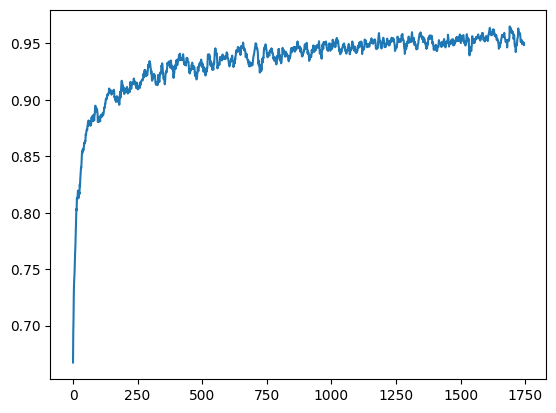

In [67]:
def moving_avg(l,n=10):
    return [sum(l[i:i+n])/n for i in range(len(l)-n+1)]


plt.plot(*zip(*enumerate(moving_avg(acc))))
plt.show()

In [68]:
loss, acc, pred, base_model = train_binary(model, 300)

[array([[-0.00860775, -0.4757676 ,  0.75331616, ...,  0.47643387,
        -0.839651  , -0.42231464],
       [-0.9954498 , -0.85768473,  0.72201145, ...,  0.0503571 ,
         0.83240867,  0.6941266 ],
       [ 0.18933535,  0.32054627,  0.7915621 , ...,  0.20395184,
         0.41739154, -0.9114026 ],
       ...,
       [-0.41448724, -0.8201879 ,  0.09487188, ...,  0.05762005,
        -0.21697938, -0.55047035],
       [ 0.46508992, -0.8642918 , -0.4326954 , ..., -0.25934136,
        -0.65829754,  0.57598174],
       [ 0.09234226, -0.89562035, -0.584816  , ...,  0.44022095,
         0.5620768 ,  0.2255199 ]], dtype=float32), array([-0.011042  , -0.97788215, -0.61545753, -0.23329496, -0.9138049 ,
       -0.14382994, -0.96752715, -0.03990066, -0.7139635 , -0.6775609 ],
      dtype=float32)]
[array([[-0.2881317 , -0.56054115,  0.85122466, ...,  0.03992426,
        -0.75216293, -0.4613651 ],
       [-0.32775724, -0.8627503 ,  0.87023294, ...,  0.02257693,
         0.5489687 ,  0.47201037],
  

2025-05-30 23:03:24.487977: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test Accuracy: 0.968800
[array([[-0.22212362, -0.44746077,  0.64634   , ...,  0.98524106,
        -0.7563722 , -0.463035  ],
       [-0.6168151 , -0.271837  ,  0.56902885, ...,  0.21807945,
         0.09554851,  0.73593783],
       [ 0.78466964,  0.7031131 ,  0.5689423 , ...,  0.3197981 ,
         0.6887704 , -0.6395892 ],
       ...,
       [-0.626578  , -0.796157  ,  0.8461858 , ...,  0.818581  ,
        -0.3923173 , -0.08301687],
       [ 0.44155645, -0.89800096, -0.37863135, ..., -0.9785534 ,
        -0.40518665,  0.62905276],
       [ 0.9849092 , -0.23025763, -0.08325171, ...,  0.7653191 ,
         0.40526807,  0.20770156]], dtype=float32), array([-0.5202292 , -0.98245597, -0.53373575, -0.3808118 , -0.39075422,
       -0.7035706 , -0.957875  , -0.72110224, -0.8771969 , -0.39907408],
      dtype=float32)]
[array([[-0.84538496, -0.27471113,  0.01671302, ...,  0.1764611 ,
        -0.36565208, -0.96385574],
       [-0.624738  , -0.6644871 ,  0.0920105 , ...,  0.02405083,
         0.94

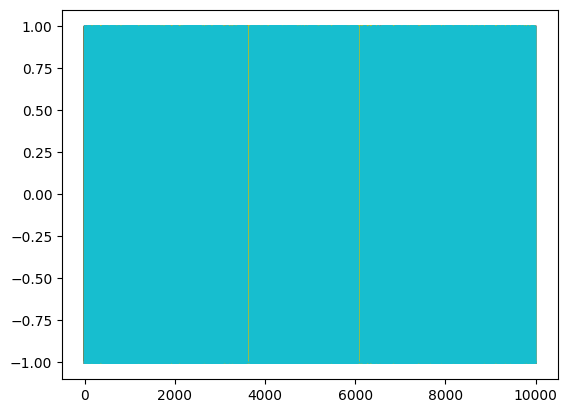

Test Accuracy: 0.938600


In [73]:
plt.plot(*zip(*enumerate(pred)))
plt.show()

pred = base_model(x_test, is_training=False)
acc = accuracy(pred, y_test)
print("Test Accuracy: %f" % acc)

# base_model.save("model_improved.keras")

In [70]:
# Build neural network model.
neural_net = NeuralNetTanH(layer=PseudoBinaryLinear)
loss, acc, _ = train(neural_net, 300)
learning_rate=0.01
loss[len(loss):], acc[len(acc):], _ = train(neural_net, 200)

plt.plot(*zip(*enumerate(loss)))
plt.savefig(output_folder / ("TanH_loss.png"))
plt.close()

plt.plot(*zip(*enumerate(acc)))
plt.savefig(output_folder / ("TanH_acc.png"))
plt.close()

binary_network = NeuralNetTanH(layer=BinaryLinear)

# # Initialize network structure
binary_network(x_test[0], is_training=False)
# binary_network2(x_test[0], is_training=False)

# # print(list(map(ops.tanh, neural_net.fc1.get_weights())))
# # print(neural_net.fc1.get_weights())
# # Copy weights
binary_network.fc1.set_weights(list(map(ops.tanh, neural_net.fc1.get_weights())))
binary_network.out.set_weights(list(map(ops.tanh, neural_net.out.get_weights())))

# binary_network2.fc1.set_weights(neural_net.fc1.get_weights())
# binary_network2.out.set_weights(neural_net.out.get_weights())

# Test model on validation set before fine-tuning.
pred = binary_network(x_test, is_training=False)
print("Test Accuracy B1: %f" % accuracy(pred, y_test))


# Fine-tune
loss, acc, _ = train(binary_network, 300, "BinaryR1")
learning_rate=0.01
loss[len(loss):], acc[len(acc):], _ = train(binary_network, 200, "BinaryR2")

plt.plot(*zip(*enumerate(loss)))
plt.savefig(output_folder / ("Binary_loss.png"))
plt.close()

plt.plot(*zip(*enumerate(acc)))
plt.savefig(output_folder / ("Binary_acc.png"))
plt.close()

step: 100, loss: 1.653975, accuracy: 0.863281
step: 200, loss: 1.644401, accuracy: 0.855469
step: 300, loss: 1.605593, accuracy: 0.869141
step: 400, loss: 1.596565, accuracy: 0.896484
step: 500, loss: 1.587853, accuracy: 0.884766
step: 600, loss: 1.564235, accuracy: 0.902344


KeyboardInterrupt: 

In [ ]:
binary_network.save("model")

In [7]:
# Test model on validation set before fine-tuning.
pred = binary_network(x_test, is_training=False)
print("Test Accuracy B1: %f" % accuracy(pred, y_test))


NameError: name 'binary_network' is not defined

In [74]:
# Testing code starts here with proper binarization

b = keras.models.load_model("model_improved.keras")

# Properly quantize weights
b.fc1.set_weights(binarized_weights(b.fc1.get_weights()))
b.out.set_weights(binarized_weights(b.out.get_weights()))

no_bias = NeuralNetTanH(layer=BinaryLinearNoBias)
no_bias(x_test[0], is_training=False)

no_bias.fc1.set_weights((b.fc1.get_weights()[0],))
no_bias.out.set_weights((b.out.get_weights()[0],))


In [75]:
# Performance stays the same
pred = no_bias(x_test, is_training=False)
print("Test Accuracy B1: %f" % accuracy(pred, y_test))

Test Accuracy B1: 0.937100


In [76]:
# Prune every node in intermediate layer to see which ones matter

def remove_nodes_i(model, i):
    fc1_w = np.delete(model.fc1.get_weights()[0], i, axis=1)
    out_w = np.delete(model.out.get_weights()[0], i, axis=0)

    b = NeuralNetTanH(layer=BinaryLinearNoBias, n_hidden_1=fc1_w.shape[1])
    b(x_test[0], is_training=False)
    b.fc1.set_weights((fc1_w,))
    b.out.set_weights((out_w,))

    return b

def evaluate_nodes(model):
    l = []

    for node_i in range(model.n_hidden):
        new_network = remove_nodes_i(model, (node_i,))
        pred = new_network(x_train, is_training=False)
        acc = accuracy(pred, y_train)

        l.append((acc, node_i))
        print(f"{node_i}: {acc}%")

    l.sort(key=lambda p: p[0], reverse=True)
    return l

In [87]:
# Prune n*5% of nodes in intermediate layer
n = 19
acc_pruned_after_20e = []

percent_skips = 5
skips = int(256 * 5 / 100)

# model = NeuralNetTanH(layer=BinaryLinearNoBias, n_hidden_1=10)
# model(x_test[0], is_training=False)
model = no_bias
l_no_bias = evaluate_nodes(no_bias)

for j in range(1, n+1):
    l = evaluate_nodes(model)
    to_remove = list(map(lambda p: p[1], l[:skips]))
    model = remove_nodes_i(model, to_remove)

    _, _, _, model = train_binary(model, 20, layer=BinaryLinearNoBias)
    pred = model(x_test, is_training=False)
    acc = accuracy(pred, y_test)
    acc_pruned_after_20e.append(acc)
    print(f"{percent_skips*skips}% 20e: {acc}%")    

    model.save(f"pruned_{j*percent_skips}_3.keras")

0: 0.13063333928585052%
1: 0.12921667098999023%
2: 0.12683333456516266%
3: 0.10530000180006027%
4: 0.12129999697208405%
5: 0.10448333621025085%
6: 0.1023833304643631%
7: 0.13988333940505981%
8: 0.11541666835546494%
9: 0.10971666872501373%
[array([], shape=(0, 10), dtype=float32)]
[array([], shape=(0, 10), dtype=float32)]
[array([], shape=(0, 10), dtype=float32)]
[array([], shape=(0, 10), dtype=float32)]
[array([], shape=(0, 10), dtype=float32)]
step: 100, loss: 2.302585, accuracy: 0.093750
step: 200, loss: 2.302585, accuracy: 0.107422
step: 300, loss: 2.302585, accuracy: 0.095703
step: 400, loss: 2.302585, accuracy: 0.089844
step: 500, loss: 2.302585, accuracy: 0.082031
step: 600, loss: 2.302585, accuracy: 0.101562
step: 700, loss: 2.302585, accuracy: 0.097656
step: 800, loss: 2.302585, accuracy: 0.134766
step: 900, loss: 2.302585, accuracy: 0.107422
step: 1000, loss: 2.302585, accuracy: 0.103516
step: 1100, loss: 2.302585, accuracy: 0.091797
step: 1200, loss: 2.302585, accuracy: 0.093

In [14]:
acc_pruned_before_training = []

for i in [skips * j for j in range(1, n+1)]:
    to_remove = list(map(lambda p: p[1], l_no_bias[:i]))
    model = remove_nodes_i(no_bias, to_remove)
    pred = model(x_test, is_training=False)
    acc = accuracy(pred, y_test)
    acc_pruned_before_training.append(acc)

In [15]:
tipping_point = np.where(np.array(acc_pruned_after_20e) < 0.9)[0][0]
pruned_tipping_point = (tipping_point) * percent_skips

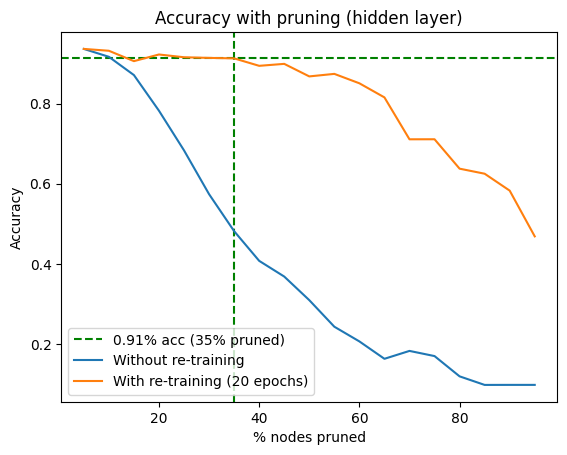

In [16]:
x = [percent_skips * j for j in range(1, n+1)]
plt.title("Accuracy with pruning (hidden layer)")
plt.axhline(acc_pruned_after_20e[tipping_point-1], linestyle="--", c = "g", label = f"{acc_pruned_after_20e[tipping_point-1]:.2}% acc ({pruned_tipping_point}% pruned)")
plt.axvline(pruned_tipping_point, linestyle="--", c = "g")
plt.plot(x, acc_pruned_before_training, label="Without re-training")
plt.plot(x, acc_pruned_after_20e, label="With re-training (20 epochs)")
plt.ylabel("Accuracy")
plt.xlabel("% nodes pruned")
plt.legend()
plt.show()

In [148]:
model = keras.models.load_model("pruned_45.keras")

# Performance stays the same
pred = model(x_test, is_training=False)
print("Test Accuracy B1: %f" % accuracy(pred, y_test))

Test Accuracy B1: 0.894300
